Muhammad Anthar Jailani Putra 11220940000029

Reyhan Maulana Aryaduta 11220940000048

# Import Library

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader, random_split
import numpy as np
import random
import os
import matplotlib.pyplot as plt
import copy

In [ ]:
# Set global seed for reproducibility
def set_seed(seed_value):
    """
    Mengatur seed untuk reproducibility di Python, NumPy, dan PyTorch.
    """
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False  # Menonaktifkan auto-tuner CuDNN
    os.environ['PYTHONHASHSEED'] = str(seed_value)

set_seed(42)  # Angka seed yang umum digunakan

# Tentukan penggunaan GPU jika tersedia, jika tidak, gunakan CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")

Menggunakan device: cuda:0


# Load Dataset

In [ ]:
# Data preprocessing and augmentation
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),  # Data augmentation: random flip
    transforms.RandomCrop(32, padding=4),  # Random crop with padding
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize as per notebook
])

transform_eval = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 dataset
train_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
eval_data = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_eval)
val_size = int(0.1 * len(train_data))
train_size = len(train_data) - val_size
train_indices, val_indices = random_split(range(len(train_data)), [train_size, val_size], generator=torch.Generator().manual_seed(42))
trainset = torch.utils.data.Subset(train_data, train_indices)
valset = torch.utils.data.Subset(eval_data, val_indices)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_eval)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:19<00:00, 8.76MB/s]


In [ ]:
from collections import Counter  # Impor Counter untuk menghitung frekuensi kelas

# Verifikasi distribusi kelas
train_labels = [train_data.targets[i] for i in train_indices]
val_labels = [eval_data.targets[i] for i in val_indices]
train_dist = Counter(train_labels)
val_dist = Counter(val_labels)

# Daftar nama kelas CIFAR-10
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Cetak distribusi kelas
print("Distribusi kelas di Train Set:")
for cls, count in sorted(train_dist.items()):
    print(f"Kelas {classes[cls]}: {count} gambar")
print("\nDistribusi kelas di Validation Set:")
for cls, count in sorted(val_dist.items()):
    print(f"Kelas {classes[cls]}: {count} gambar")

print(f"\nJumlah gambar di Train Set: {len(trainset)}")
print(f"Jumlah gambar di Validation Set: {len(valset)}")

Distribusi kelas di Train Set:
Kelas plane: 4512 gambar
Kelas car: 4488 gambar
Kelas bird: 4468 gambar
Kelas cat: 4529 gambar
Kelas deer: 4529 gambar
Kelas dog: 4486 gambar
Kelas frog: 4493 gambar
Kelas horse: 4500 gambar
Kelas ship: 4496 gambar
Kelas truck: 4499 gambar

Distribusi kelas di Validation Set:
Kelas plane: 488 gambar
Kelas car: 512 gambar
Kelas bird: 532 gambar
Kelas cat: 471 gambar
Kelas deer: 471 gambar
Kelas dog: 514 gambar
Kelas frog: 507 gambar
Kelas horse: 500 gambar
Kelas ship: 504 gambar
Kelas truck: 501 gambar

Jumlah gambar di Train Set: 45000
Jumlah gambar di Validation Set: 5000


## Train Function

In [ ]:
def train_and_evaluate(model, trainloader, valloader, testloader,
                       criterion, optimizer, epochs, patience, evaluate_test=False):

    scheduler = lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0

    if evaluate_test == False:
      for epoch in range(epochs):
          # training
          model.train()
          running_loss = 0.0
          correct = 0
          total = 0
          for inputs, labels in trainloader:
              inputs, labels = inputs.to(device), labels.to(device)
              optimizer.zero_grad()
              outputs = model(inputs)
              loss = criterion(outputs, labels)
              loss.backward()
              optimizer.step()

              running_loss += loss.item() * inputs.size(0)
              _, preds = torch.max(outputs, 1)
              correct += (preds == labels).sum().item()
              total += labels.size(0)

          train_loss = running_loss / total
          train_acc = correct / total
          train_losses.append(train_loss)
          train_accs.append(train_acc)

          # validation
          model.eval()
          val_loss = 0.0
          val_correct = 0
          val_total = 0
          with torch.no_grad():
              for inputs, labels in valloader:
                  inputs, labels = inputs.to(device), labels.to(device)
                  outputs = model(inputs)
                  loss = criterion(outputs, labels)
                  val_loss += loss.item() * inputs.size(0)
                  _, preds = torch.max(outputs, 1)
                  val_correct += (preds == labels).sum().item()
                  val_total += labels.size(0)

          val_loss = val_loss / val_total
          val_acc = val_correct / val_total
          val_losses.append(val_loss)
          val_accs.append(val_acc)

          # Print hasil training dan validation tiap epoch
          print(f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc*100:.2f}% | "
                f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc*100:.2f}%")

          # scheduler step
          scheduler.step(val_acc)

          # early stopping
          if val_acc > best_val_acc:
              best_val_acc = val_acc
              best_model_wts = copy.deepcopy(model.state_dict())
              patience_counter = 0
          else:
              patience_counter += 1
              if patience_counter >= patience:
                  print(f"Early stopping at epoch {epoch+1}")
                  break

    model.load_state_dict(best_model_wts)
    if evaluate_test:
        model.eval()
        test_preds, test_labels = [], []
        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_labels.extend(labels.cpu().numpy())
        test_acc = 100 * sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels)
        print(f'Test Accuracy: {test_acc:.2f}%')
        return train_losses, val_losses, train_accs, val_accs, test_preds, test_labels, best_val_acc

    return train_losses, val_losses, train_accs, val_accs, best_val_acc


## Model

In [ ]:
# Define the enhanced CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)  # Increased filters to 64
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)  # Increased to 128
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)  # Increased to 256
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 1024)  # Adjusted for new filter size
        self.fc2 = nn.Linear(1024, 10)
        self.dropout = nn.Dropout(0.4)  # Reduced dropout to 0.4
        self.batchnorm1 = nn.BatchNorm2d(64)
        self.batchnorm2 = nn.BatchNorm2d(128)
        self.batchnorm3 = nn.BatchNorm2d(256)

    def forward(self, x):
        x = self.pool(F.relu(self.batchnorm1(self.conv1(x))))
        x = self.pool(F.relu(self.batchnorm2(self.conv2(x))))
        x = self.pool(F.relu(self.batchnorm3(self.conv3(x))))
        x = x.view(-1, 256 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## Hyperparameter Tuning

In [ ]:
# Hyperparameter tuning with reduced epochs
learning_rates = [0.001, 0.003]
batch_sizes = [32, 64]
best_val_acc = 0
best_params = {}
best_model = None

for lr in learning_rates:
    for bs in batch_sizes:
        print(f'\n🔍 Tuning: lr={lr}, batch_size={bs}')

        trainloader = DataLoader(trainset, batch_size=bs, shuffle=True)
        valloader = DataLoader(valset, batch_size=bs, shuffle=False)
        testloader = DataLoader(testset, batch_size=bs, shuffle=False)

        model = CustomCNN().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)

        train_losses, val_losses, train_accs, val_accs, curr_best_val_acc = train_and_evaluate(
            model, trainloader, valloader, testloader,
            criterion, optimizer, epochs=10, patience=5, evaluate_test=False
        )

        if curr_best_val_acc > best_val_acc:
            best_val_acc = curr_best_val_acc
            best_params = {'lr': lr, 'batch_size': bs}
            best_model = copy.deepcopy(model)
            best_train_losses = train_losses
            best_val_losses = val_losses
            best_train_accs = train_accs
            best_val_accs = val_accs

print(f'\n✅ Best Hyperparameters: {best_params}, Validation Accuracy: {best_val_acc:.4f}')



🔍 Tuning: lr=0.001, batch_size=32
Epoch 1/10 | Train Loss: 1.5975, Train Acc: 41.98% | Val Loss: 1.1724, Val Acc: 58.00%
Epoch 2/10 | Train Loss: 1.2270, Train Acc: 56.33% | Val Loss: 1.0488, Val Acc: 62.98%
Epoch 3/10 | Train Loss: 1.0597, Train Acc: 62.85% | Val Loss: 0.8624, Val Acc: 69.58%
Epoch 4/10 | Train Loss: 0.9619, Train Acc: 66.62% | Val Loss: 0.7926, Val Acc: 72.06%
Epoch 5/10 | Train Loss: 0.8756, Train Acc: 69.62% | Val Loss: 0.7208, Val Acc: 74.60%
Epoch 6/10 | Train Loss: 0.8158, Train Acc: 72.01% | Val Loss: 0.6797, Val Acc: 75.94%
Epoch 7/10 | Train Loss: 0.7609, Train Acc: 73.94% | Val Loss: 0.6480, Val Acc: 78.30%
Epoch 8/10 | Train Loss: 0.7149, Train Acc: 75.99% | Val Loss: 0.5848, Val Acc: 79.32%
Epoch 9/10 | Train Loss: 0.6785, Train Acc: 77.20% | Val Loss: 0.5944, Val Acc: 79.24%
Epoch 10/10 | Train Loss: 0.6479, Train Acc: 78.22% | Val Loss: 0.5330, Val Acc: 81.84%

🔍 Tuning: lr=0.001, batch_size=64
Epoch 1/10 | Train Loss: 1.5852, Train Acc: 42.56% | Val Lo

In [ ]:
torch.save(best_model.state_dict(), 'model_CNN_new.pth')
print("Best CNN model saved as 'model_CNN_new.pth'")

Best CNN model saved as 'model_CNN_new.pth'


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# # Simpan model ke folder di Google Drive
# torch.save(best_model.state_dict(), '/content/drive/MyDrive/Colab Notebooks/Model/model_CNN_new.pth')
# print("Best CNN model saved to Google Drive as 'model_CNN_new.pth'")


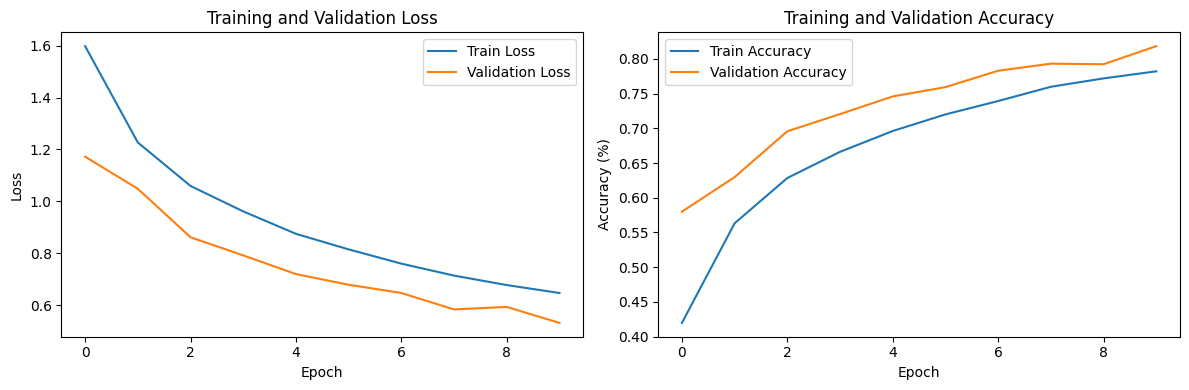

In [ ]:
# Training and Validation Loss & Accuracy Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(best_train_losses, label='Train Loss')
plt.plot(best_val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(best_train_accs, label='Train Accuracy')
plt.plot(best_val_accs, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.savefig('training_validation_plots.png')
plt.show()

In [ ]:
# Evaluate the best model on the test set
print('\nEvaluating best model on test set:')
trainloader = DataLoader(trainset, batch_size=best_params['batch_size'], shuffle=True)
valloader = DataLoader(valset, batch_size=best_params['batch_size'], shuffle=False)
testloader = DataLoader(testset, batch_size=best_params['batch_size'], shuffle=False)
train_losses, val_losses, train_accs, val_accs, test_preds, test_labels, best_val_acc = train_and_evaluate(
    best_model, trainloader, valloader, testloader, criterion, optimizer,
    epochs=1, patience=15, evaluate_test=True)


Evaluating best model on test set:
Test Accuracy: 81.20%


In [ ]:
# Tampilkan Akurasi dari Hasil Pelatihan
final_train_acc = best_train_accs[-1] if best_train_accs else 0
final_val_acc = best_val_acc
print('\nFinal Accuracies:')
print(f'Training Accuracy: {final_train_acc:.2f}%')
print(f'Validation Accuracy: {final_val_acc:.2f}%')
print(f'Test Accuracy: {100 * sum(np.array(test_preds) == np.array(test_labels)) / len(test_labels):.2f}%')


Final Accuracies:
Training Accuracy: 0.78%
Validation Accuracy: 0.00%
Test Accuracy: 81.20%


## Evaluasi

In [ ]:
# !pip install gdown
# import gdown

# # ID file Google Drive
# file_id = "1Od4pars-qFDw0c3p1cDZMMBTUYRdgKNc"
# output_path = "model_CNN_new.pth"

# # Download file
# gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

model_cnn = CustomCNN()
model_cnn.load_state_dict(torch.load("model_CNN_new.pth"), map_location=torch.device(device))

<All keys matched successfully>

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

In [ ]:
def test(model, loader, device='cpu'):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            preds.extend(pred.cpu().numpy())
            targets.extend(target.cpu().numpy())
    return np.array(preds), np.array(targets)

In [ ]:
cnn_preds, cnn_targets = test(model_cnn, testloader, "cpu")

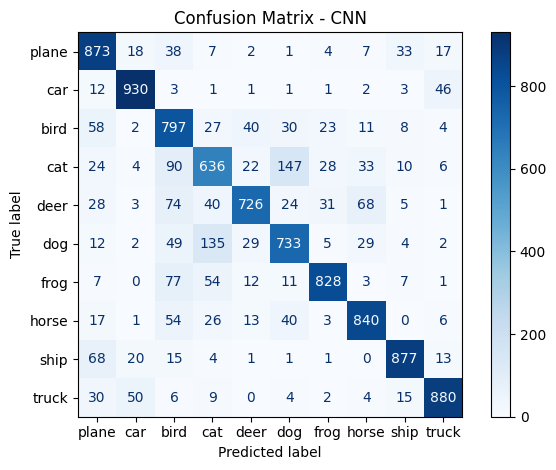

In [ ]:
cm_cnn = confusion_matrix(cnn_targets, cnn_preds)
disp_cnn = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=classes)

disp_cnn.plot(cmap='Blues')
plt.title("Confusion Matrix - CNN")
plt.tight_layout()
plt.show()


In [ ]:
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

In [ ]:
cnn_metrics = compute_metrics(cnn_targets, cnn_preds)

metrics_df = pd.DataFrame([cnn_metrics], index= ['CNN'])
metrics_df

,Accuracy,Precision (macro),Recall (macro),F1 Score (macro)
CNN,0.812,0.816304,0.812,0.812418


## Feature Maps

In [ ]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

In [ ]:
# Define the enhanced CNN architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, 3, padding=1)  # Increased filters to 64
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1)  # Increased to 128
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1)  # Increased to 256
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 4 * 4, 1024)  # Adjusted for new filter size
        self.fc2 = nn.Linear(1024, 10)
        self.dropout = nn.Dropout(0.4)  # Reduced dropout to 0.4
        self.batchnorm1 = nn.BatchNorm2d(64)
        self.batchnorm2 = nn.BatchNorm2d(128)
        self.batchnorm3 = nn.BatchNorm2d(256)

    def forward(self, x):
        fmap1 = self.pool(F.relu(self.batchnorm1(self.conv1(x))))
        fmap2 = self.pool(F.relu(self.batchnorm2(self.conv2(fmap1))))
        x = self.pool(F.relu(self.batchnorm3(self.conv3(fmap2))))
        x = x.view(-1, 256 * 4 * 4)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x, fmap1, fmap2

In [ ]:
weights = torch.load("model_CNN_new.pth")
model_cnn = CustomCNN()
model_cnn.load_state_dict(weights)

<All keys matched successfully>

In [ ]:
cnn = CustomCNN()  # Membuat instance dari model CNN yang sudah didefinisikan sebelumnya
cnn.load_state_dict(torch.load("model_CNN_new.pth"))  # Memuat bobot (weights) yang sudah dilatih dari file 'model_CNN_new.pth'
cnn.eval()  # Mengatur model ke mode evaluasi (tidak ada dropout, batchnorm pakai rata-rata statistik)

with torch.no_grad():  # Blok ini menonaktifkan perhitungan gradien untuk menghemat memori dan mempercepat proses
    outputs, fmap1, fmap2 = cnn(images)  # Forward pass: menghasilkan output prediksi dan feature map (jika model Anda memang mengembalikannya)
    preds = outputs.argmax(dim=1)  # Mengambil indeks kelas dengan nilai tertinggi sebagai prediksi (argmax dari logits)


In [ ]:
correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
# Membandingkan prediksi dengan label sebenarnya → menghasilkan tensor boolean
# .nonzero(as_tuple=True) menghasilkan indeks dari prediksi yang benar
# [0] digunakan untuk mengambil tensor indeksnya saja (bukan tuple)

wrong_indices = (preds != labels).nonzero(as_tuple=True)[0]
# Sama seperti sebelumnya, tapi untuk prediksi yang salah

correct_idx = correct_indices[0].item() if correct_indices.numel() > 0 else 0
# Mengambil indeks pertama dari prediksi yang benar
# Jika tidak ada prediksi benar, fallback ke indeks 0 (agar tidak error)

wrong_idx = wrong_indices[0].item() if wrong_indices.numel() > 0 else correct_idx
# Mengambil indeks pertama dari prediksi yang salah
# Jika tidak ada prediksi salah, fallback ke indeks yang benar (agar tetap punya satu sampel)


In [ ]:
_, fmap1_correct, _ = cnn(images[correct_idx].unsqueeze(0))
# Menjalankan forward pass untuk gambar dengan prediksi benar
# images[correct_idx] → Mengambil satu gambar
# .unsqueeze(0) → Menambahkan dimensi batch (ubah shape dari [3, 32, 32] ke [1, 3, 32, 32])
# cnn(...) → Menjalankan model, mengembalikan output, fmap1, dan fmap2
# _ → Abaikan output dan fmap2, hanya simpan fmap1 (misalnya untuk visualisasi)

_, fmap1_wrong, _ = cnn(images[wrong_idx].unsqueeze(0))
# Sama seperti di atas, tapi untuk gambar dengan prediksi salah


In [ ]:
def plot_feature_maps(input_img, fmap, title, label, num_channels=4):
    fig, ax = plt.subplots(1, num_channels + 1, figsize=(20, 4))

    # Gambar input asli tanpa diubah
    img = input_img[0].detach().cpu()
    if img.shape[0] == 3:
        img = img.permute(1, 2, 0)  # CHW -> HWC for RGB
    else:
        img = img[0]  # Grayscale

    ax[0].imshow(img.numpy(), cmap='gray' if img.ndim == 2 else None)
    ax[0].axis('off')

    # Normalisasi dan tampilkan feature maps dengan label layer
    for i in range(num_channels):
        fmap_i = fmap[0, i].detach().cpu().numpy()
        fmap_i = (fmap_i - fmap_i.min()) / (fmap_i.max() - fmap_i.min() + 1e-6)
        ax[i + 1].imshow(fmap_i, cmap='viridis')
        ax[i + 1].axis('off')

    fig.suptitle(title, fontsize=16)
    plt.subplots_adjust(wspace=0.1, hspace=0)
    plt.show()


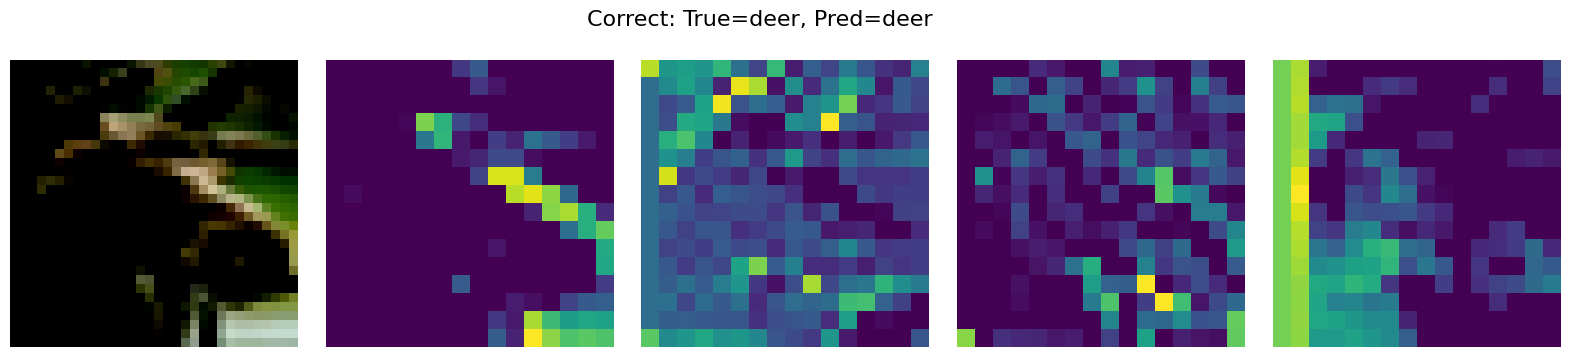

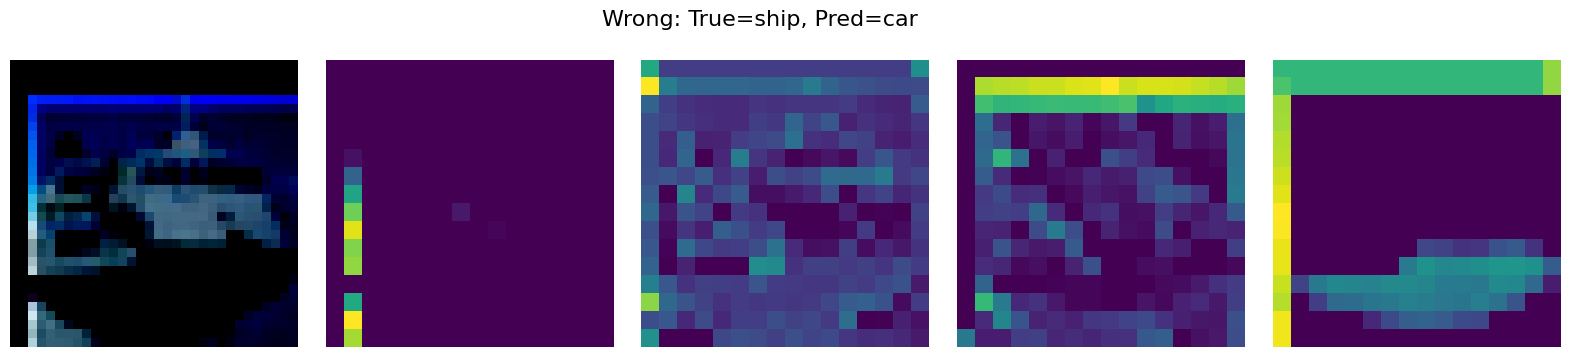

In [ ]:
plot_feature_maps(
    input_img=images[correct_idx].unsqueeze(0),
    fmap=fmap1_correct,
    title=f"Correct: True={classes[labels[correct_idx]]}, Pred={classes[preds[correct_idx]]}",
    label=labels[correct_idx].item()
)

plot_feature_maps(
    input_img=images[wrong_idx].unsqueeze(0),
    fmap=fmap1[wrong_idx].unsqueeze(0),
    title=f"Wrong: True={classes[labels[wrong_idx]]}, Pred={classes[preds[wrong_idx]]}",
    label=labels[wrong_idx].item()
)

In [ ]:
print("Wrong Predictions and Visualizations:")
for idx, y in enumerate(wrong_indices):
    true_label = labels[y].item()
    pred_label = preds[y].item()

    print(f"{idx+1}. Wrong: Index = {y.item()} - Pred: {classes[pred_label]}, True: {classes[true_label]}")


print(f"\nTotal wrong predictions: {len(wrong_indices)}")


Wrong Predictions and Visualizations:
1. Wrong: Index = 3 - Pred: car, True: ship
2. Wrong: Index = 8 - Pred: bird, True: frog
3. Wrong: Index = 19 - Pred: cat, True: dog
4. Wrong: Index = 24 - Pred: deer, True: horse
5. Wrong: Index = 27 - Pred: dog, True: cat
6. Wrong: Index = 29 - Pred: ship, True: bird

Total wrong predictions: 6


## Grad-Cam

In [ ]:
import torch

def generate_gradcam(model, image, target_class, final_conv_layer):
    model.eval()
    gradients = []
    activations = []

    def save_gradient_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def save_activation_hook(module, input, output):
        activations.append(output)

    # Ambil layer konvolusi terakhir dari model berdasarkan namanya
    conv_layer = dict([*model.named_modules()])[final_conv_layer]

    # Debugging: Cek hook backward biasa sebelum pembersihan
    print("Hook backward biasa sebelum pembersihan:", conv_layer._backward_hooks)

    # Hapus hook backward biasa jika ada
    if hasattr(conv_layer, '_backward_hooks') and conv_layer._backward_hooks:
        conv_layer._backward_hooks.clear()

    # Debugging: Cek lagi setelah pembersihan
    print("Hook backward biasa setelah pembersihan:", conv_layer._backward_hooks)

    h1 = conv_layer.register_forward_hook(save_activation_hook)
    h2 = conv_layer.register_backward_hook(save_gradient_hook)  # Gunakan backward hook biasa

    # Forward pass
    image = image.unsqueeze(0)  # Tambahkan batch dimension
    image = image.to(next(model.parameters()).device)  # Pastikan device sesuai

    output,_,_ = model(image)
    pred_class = output.argmax(dim=1)

    # Backward pass
    model.zero_grad()
    loss = output[0, target_class]
    loss.backward()

    # Ambil activations dan gradients
    grads_val = gradients[0].squeeze(0)      # [C, H, W]
    act_val = activations[0].squeeze(0)      # [C, H, W]

    # Grad-CAM = ReLU(Σ (w_k * A_k)), dengan w_k = rata-rata grad pada channel k
    weights = grads_val.mean(dim=(1, 2))     # [C]
    cam = torch.sum(weights[:, None, None] * act_val, dim=0)  # [H, W]
    cam = torch.relu(cam)

    # Normalisasi
    cam -= cam.min()
    cam /= cam.max()
    cam = cam.cpu().detach().numpy()

    # Hapus hooks
    h1.remove()
    h2.remove()

    return cam, pred_class.item()

In [ ]:
def denormalize(image_tensor):
    # CIFAR-10 normalize: (x - 0.5)/0.5 -> inverse: x*0.5 + 0.5
    image_tensor = image_tensor * 0.5 + 0.5
    return image_tensor.clamp(0, 1)

def to_grayscale(image_tensor):
    # image_tensor shape: (3, H, W)
    # convert to grayscale using luminosity method
    r, g, b = image_tensor[0], image_tensor[1], image_tensor[2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

def plot_gradcam(image_tensor, cam, label, pred):
    # Denormalize
    image_denorm = denormalize(image_tensor.cpu())
    # Convert to grayscale
    gray_image = to_grayscale(image_denorm).numpy()

    plt.figure(figsize=(8, 4))

    # Gunakan classes[label] untuk true label dan classes[pred] untuk prediksi
    plt.subplot(1, 2, 1)
    plt.title(f"Original - True: {classes[label]}")
    plt.imshow(gray_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM - Pred: {classes[pred]}")
    plt.imshow(gray_image, cmap='gray')
    plt.imshow(cam, cmap='jet', alpha=0.5)  # overlay CAM
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
idx = 321
image, label = testloader.dataset[idx]
image = image.to(device)


Hook backward biasa sebelum pembersihan: OrderedDict([(1, <function generate_gradcam.<locals>.save_gradient_hook at 0x78ae6f68d6c0>)])
Hook backward biasa setelah pembersihan: OrderedDict()


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


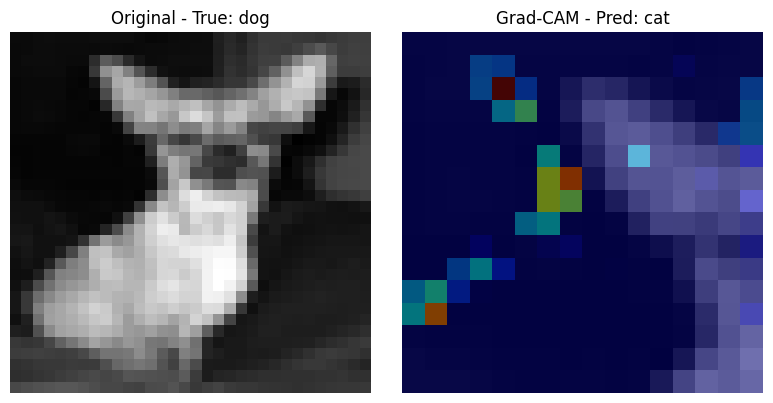

In [ ]:
# Panggil fungsi
cam, pred = generate_gradcam(model_cnn, image, label, "conv2")
plot_gradcam(image, cam, label=label, pred=pred)

In [ ]:
idx = 9
image, label = testloader.dataset[idx]
image = image.to(device)

Hook backward biasa sebelum pembersihan: OrderedDict()
Hook backward biasa setelah pembersihan: OrderedDict()


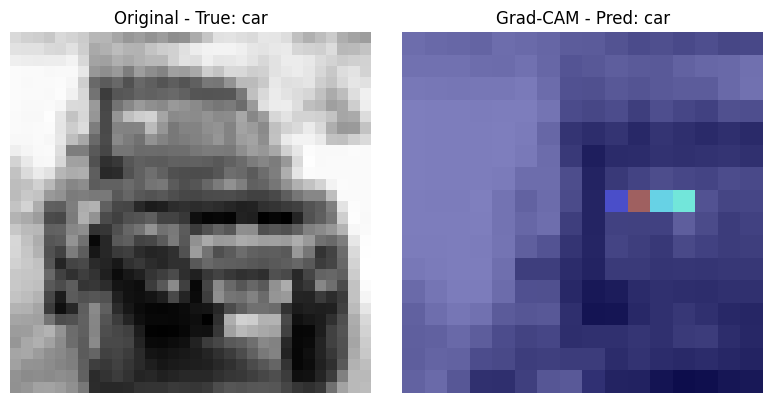

In [ ]:
cam, pred = generate_gradcam(model_cnn, image, label, "conv2")
plot_gradcam(image, cam, label=label, pred=pred)